# Etapa 2 - Rede Neural Convolucional (CNN)

Nesta etapa foi desenvolvida uma Rede Neural Convolucional utilizando PyTorch e TorchVision para classificação de imagens de cães e gatos.

O modelo foi construído manualmente, sem utilização de arquiteturas prontas ou modelos pré-treinados, conforme exigido no enunciado.

In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

Verificação do Hardware

In [3]:
print("PyTorch:", torch.__version__)
print("GPU disponível:", torch.cuda.is_available())

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Dispositivo:", device)

PyTorch: 2.12.1+cpu
GPU disponível: False
Dispositivo: cpu


## Dataset

O conjunto de dados utilzado contém imagens de cães e gatos previamente divididas em:

- Treinamento
- Validação
- Teste

Pré-processamento e Data Augmentation

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor()
])

In [5]:
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

Carregamento dos Dados

In [6]:
train_dataset = datasets.ImageFolder(
    "data/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    "data/validation",
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    "data/test",
    transform=test_transform
)

DataLoaders

In [7]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

Imagens

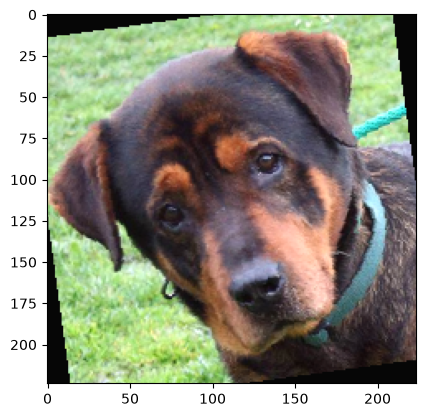

In [8]:
images, labels = next(iter(train_loader))

plt.imshow(
    images[0].permute(1,2,0)
)
plt.show()

## Arquitetura da Rede

A CNN foi composta por:

- 2 camadas convolucionais
- 2 ativações ReLU
- 2 camadas MaxPooling
- 2 camadas totalmente conectadas

In [9]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        #Bloco convolucional 1
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        #Bloco convolucional 2
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        #Pooling
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        #Camadas totalmente conectadas
        self.fc1 = nn.Linear(
            64 * 56 * 56,
            128
        )

        self.fc2 = nn.Linear(
            128,
            1
        )

        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.pool(
            self.relu(self.conv1(x))
        )

        x = self.pool(
            self.relu(self.conv2(x))
        )

        x = torch.flatten(x,1)

        x = self.relu(self.fc1(x))

        x = self.fc2(x)

        return x

In [10]:
model = CNN()
print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=200704, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (relu): ReLU()
)


## Configuração dos Hiperparâmetros

In [11]:
learning_rate = 0.001
batch_size = 32
epochs = 20

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate
)

Dispositivo (CPU/GPU)

In [12]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print("Dispositivo utilizado:", device)

Dispositivo utilizado: cpu


Loop de treinamento

In [13]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []

## Treinamento da Rede

In [14]:
for epoch in range(epochs):

    # ===== TREINAMENTO =====
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = (torch.sigmoid(outputs) > 0.5).float()

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ===== VALIDAÇÃO =====

    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).float()

            val_correct += (preds == labels).sum().item()

            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/20] Train Loss: 1.7247 Train Acc: 0.5000 Val Loss: 0.6878 Val Acc: 0.4800
Epoch [2/20] Train Loss: 0.6943 Train Acc: 0.5000 Val Loss: 0.6849 Val Acc: 0.5000
Epoch [3/20] Train Loss: 0.6944 Train Acc: 0.5000 Val Loss: 0.6870 Val Acc: 0.5000
Epoch [4/20] Train Loss: 0.6947 Train Acc: 0.5000 Val Loss: 0.6878 Val Acc: 0.5000
Epoch [5/20] Train Loss: 0.6934 Train Acc: 0.5000 Val Loss: 0.6883 Val Acc: 0.5000
Epoch [6/20] Train Loss: 0.6932 Train Acc: 0.5033 Val Loss: 0.6883 Val Acc: 0.5000
Epoch [7/20] Train Loss: 0.6931 Train Acc: 0.5033 Val Loss: 0.6898 Val Acc: 0.5000
Epoch [8/20] Train Loss: 0.6927 Train Acc: 0.5067 Val Loss: 0.6898 Val Acc: 0.5000
Epoch [9/20] Train Loss: 0.6922 Train Acc: 0.5033 Val Loss: 0.6890 Val Acc: 0.5000
Epoch [10/20] Train Loss: 0.6924 Train Acc: 0.5433 Val Loss: 0.6870 Val Acc: 0.4600
Epoch [11/20] Train Loss: 0.6671 Train Acc: 0.6400 Val Loss: 0.6713 Val Acc: 0.4900
Epoch [12/20] Train Loss: 0.6770 Train Acc: 0.6000 Val Loss: 0.6885 Val Acc: 0.5300
E

## Avaliação no Conjunto de Teste

In [15]:
y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = (
            torch.sigmoid(outputs) > 0.5
        ).int()

        y_true.extend(labels.numpy())

        y_pred.extend(
            preds.cpu().numpy().flatten()
        )

In [16]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

print(
    f"Acurácia no teste: {accuracy:.4f}"
)

Acurácia no teste: 0.6800


In [17]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Cat",
            "Dog"
        ]
    )
)

              precision    recall  f1-score   support

         Cat       0.65      0.80      0.71        50
         Dog       0.74      0.56      0.64        50

    accuracy                           0.68       100
   macro avg       0.69      0.68      0.68       100
weighted avg       0.69      0.68      0.68       100



In [18]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[40 10]
 [22 28]]


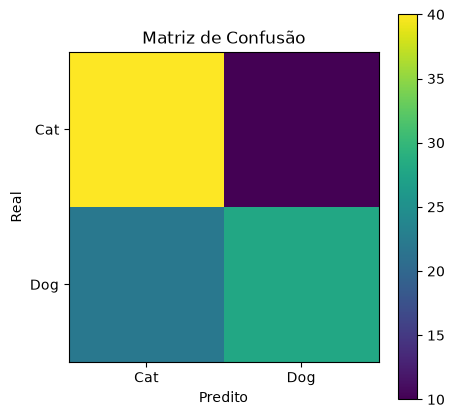

In [19]:
plt.figure(figsize=(5,5))

plt.imshow(cm)

plt.colorbar()

plt.xticks([0,1], ["Cat","Dog"])
plt.yticks([0,1], ["Cat","Dog"])

plt.xlabel("Predito")
plt.ylabel("Real")

plt.title("Matriz de Confusão")

plt.show()

Gráfico de Loss

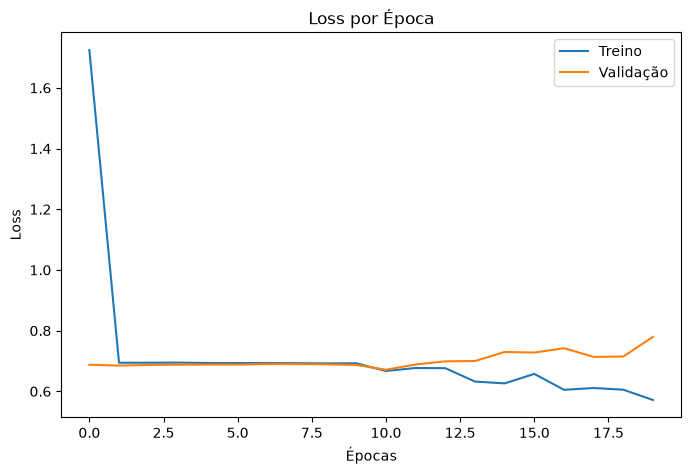

In [20]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Treino")
plt.plot(val_losses, label="Validação")

plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.title("Loss por Época")

plt.legend()

plt.show()

Gráfico de Accuracy

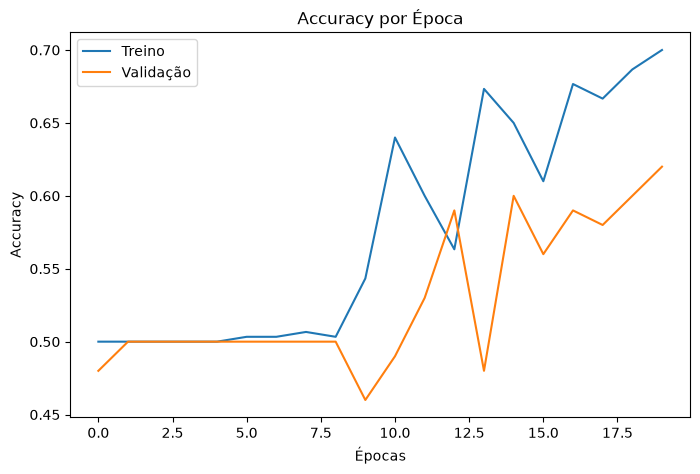

In [21]:
plt.figure(figsize=(8,5))

plt.plot(train_accs, label="Treino")
plt.plot(val_accs, label="Validação")

plt.xlabel("Épocas")
plt.ylabel("Accuracy")

plt.title("Accuracy por Época")

plt.legend()

plt.show()

In [22]:
images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([32, 1])
